In [1]:
import time
import matplotlib.pyplot as plt 
import os
os.chdir('../')
import torch
import numpy as np
import torch.nn as nn
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import random 
import psutil
from decimal import Decimal
import deepwave
import warnings
import torch.nn.functional as F
from functools import partial
from torchaudio.functional import biquad
from scipy.signal import butter
warnings.filterwarnings('ignore')
import os
from ultils.utils import *
from pyramid_loss import PyramidLoss
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [2]:
gpu_count = torch.cuda.device_count()
print(f"The number of available GPUs is: {gpu_count}")
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print(f"The selected GPU device is: {torch.cuda.get_device_name(DEVICE)}")
else:
    DEVICE = torch.device("cpu")
    print("No available GPUs detected, switched to using CPU")

The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


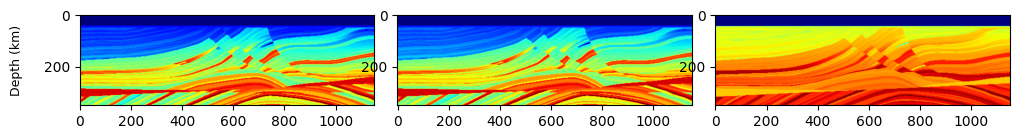

max values: tensor(4766.6040) tensor(2752.) tensor(2626.9998)
min values: tensor(1500.) tensor(800.) tensor(1009.)
model shape: torch.Size([352, 1150]) torch.Size([352, 1150]) torch.Size([352, 1150])


In [3]:
######### load data #########
dx = 10

vp_true = torch.tensor(np.load('./marmousi_model/vp_truex352x1150x10.npy'))
vs_true = torch.tensor(np.load('./marmousi_model/vs_truex352x1150x10.npy'))
rho_true = torch.tensor(np.load('./marmousi_model/rho_truex352x1150x10.npy'))


submarine_deep = 43
submarine_vp = 1500                                      #water layer vp
submarine_vs = 800  ##to obay the CFL condition                                         #water layer vs
submarine_rho = 1009
  
vp_true[:submarine_deep,:] = submarine_vp
vs_true[:submarine_deep,:] = submarine_vs
rho_true[:submarine_deep,:] = submarine_rho


fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_true.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_true.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_true.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()
print("max values:",vp_true.max(),vs_true.max(),rho_true.max())
print("min values:",vp_true.min(),vs_true.min(),rho_true.min())
print("model shape:",vp_true.shape,vs_true.shape,rho_true.shape)

17.387997
tensor(3927.0754, device='cuda:0') tensor(1847.8777, device='cuda:0')
tensor(1009., device='cuda:0') tensor(2409.4448, device='cuda:0')


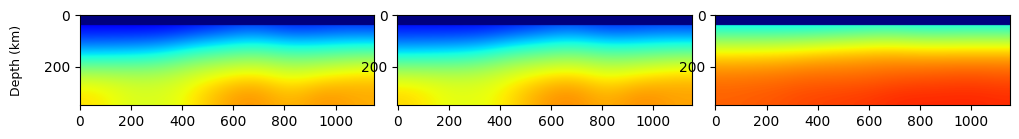

In [4]:
import scipy.ndimage
import scipy.io

sigma = 30

times = 6
if times != 0:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_n_times(vp_true, vs_true, rho_true, sigma, times, DEVICE)
else:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_once(vp_true, vs_true, rho_true, sigma, DEVICE)

snr_vp = ComputeSNR(vp_initial.detach().cpu().numpy(), \
                  vp_true.detach().cpu().numpy())

print(snr_vp)
print(vp_initial.max(),vp_initial.min())
vp_initial[:submarine_deep,:] = submarine_vp
vs_initial[:submarine_deep,:] = submarine_vs
rho_initial[:submarine_deep,:] = submarine_rho

print(rho_initial.min(),rho_initial.max())

fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_initial.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_initial.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_initial.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()

In [5]:
loss_fn = 'l1'  

if times != 0:
    ##### save path
    vp_save_path = f'./rec/reconstruction_loss/EFWI_lap_en/init_2/vp/'
    vs_save_path = f'./rec/reconstruction_loss/EFWI_lap_en/init_2/vs/'
    rho_save_path = f'./rec/reconstruction_loss/EFWI_lap_en/init_2/rho/'
    main_path = f'./log_data/log_data_loss/EFWI_lap_en/init_2/'
else:
    vp_save_path = f'./rec/reconstruction_loss/EFWI_lap_en/init_1/vp/'
    vs_save_path = f'./rec/reconstruction_loss/EFWI_lap_en/init_1/vs/'
    rho_save_path = f'./rec/reconstruction_loss/EFWI_lap_en/init_1/rho/'
    main_path = f'./log_data/log_data_loss/EFWI_lap_en/init_1/'


if not os.path.exists(main_path):
    os.makedirs(main_path)

if not os.path.exists(vp_save_path):
    os.makedirs(vp_save_path)
if not os.path.exists(vs_save_path):
    os.makedirs(vs_save_path)
if not os.path.exists(rho_save_path):
    os.makedirs(rho_save_path)
    


In [6]:
Physics = Physics_deepwave                              
                           
model_shape = [vp_true.shape[0], vp_true.shape[1]]                                 
                                                                                       
DT = 0.006                                               
F_PEAK = 8                                              
DH = dx                                                  

inpa = {                                
    'fdom': F_PEAK, 
    'dh': DH,   
    'dt': DT
}

NT = 2500

In [7]:
### load obs and src, src_loc, rec_loc
obs_file_vx = './obs_data/d_obs_vx_src.npy'
obs_file_vy = './obs_data/d_obs_vy_src.npy'
d_obs_vx = torch.tensor(np.load(obs_file_vx))
d_obs_vy = torch.tensor(np.load(obs_file_vy))

src_loc = torch.tensor(np.load('./src_rec_positions/src_loc.npy'))
rec_loc = torch.tensor(np.load('./src_rec_positions/rec_loc.npy'))
src     = torch.tensor(np.load('./sources/src.npy'))

### sum source
num_super_sources = 10
sources_per_super = 10
source_distribution = 'random'# ('random' 或 'uniform')

#### 1.
result = encode_sources(obs_data_vx = d_obs_vx.squeeze(0),
                        obs_data_vy = d_obs_vy.squeeze(0),
                        source_locations = src_loc, 
                        receiver_locations  = rec_loc, 
                        source_functions = src,
                        num_super_sources = num_super_sources,
                        sources_per_super = sources_per_super,
                        source_distribution=source_distribution
                        )

#### 2
print(f"Encoded observation data shape (vx): {result['encoded_obs_data_vx'].shape}")
print(f"Encoded observation data shape (vy): {result['encoded_obs_data_vy'].shape}")
print(f"Encoded source location shape: {result['encoded_source_locations'].shape}")
print(f"Encoded receiver location shape: {result['encoded_receiver_locations'].shape}")
print(f"Encoded source function shape: {result['encoded_source_functions'].shape}")


d_obs_vx_encode = result['encoded_obs_data_vx'].unsqueeze(0).to(DEVICE)
d_obs_vy_encode = result['encoded_obs_data_vy'].unsqueeze(0).to(DEVICE)
src_loc_encode  = result['encoded_source_locations'].to(DEVICE)
rec_loc_encode  = result['encoded_receiver_locations'].to(DEVICE)
src_encode      = result['encoded_source_functions'].to(DEVICE)



Encoded observation data shape (vx): torch.Size([10, 2500, 1130])
Encoded observation data shape (vy): torch.Size([10, 2500, 1130])
Encoded source location shape: torch.Size([10, 10, 2])
Encoded receiver location shape: torch.Size([10, 1130, 2])
Encoded source function shape: torch.Size([10, 10, 2500])


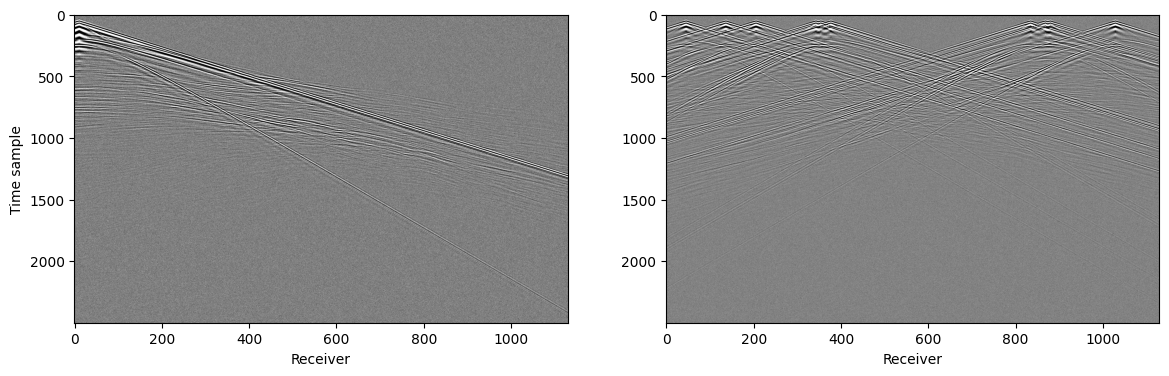

In [8]:

##### show these data
d_obs_vx_plot = d_obs_vx.squeeze(0)
d_obs_vx_en_plot = d_obs_vx_encode.squeeze(0)
vmin, vmax = torch.quantile(d_obs_vx_plot[1],
                            torch.tensor([0.01, 0.99]))
vsmin, vsmax = torch.quantile(d_obs_vx_en_plot[1],
                                 torch.tensor([0.01, 0.99]).to(DEVICE))


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(d_obs_vx_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vmin, vmax=vmax)
ax[0].set_xlabel("Receiver")
ax[0].set_ylabel("Time sample")
ax[1].imshow(d_obs_vx_en_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vsmin, vmax=vsmax)
ax[1].set_xlabel("Receiver")
plt.subplots_adjust(hspace=0.6)  
plt.show()


In [9]:
vp_initial = vp_initial.to(DEVICE)
vs_initial = vs_initial.to(DEVICE)
rho_initial = rho_initial.to(DEVICE)
vp = vp_initial.requires_grad_(True)
vs = vs_initial.requires_grad_(True)
rho = rho_initial.requires_grad_(True)

criteria = torch.nn.L1Loss(reduction='sum')
criteria_model = torch.nn.L1Loss(reduction='sum')

optimer = torch.optim.Adam([{'params': [vp], 'lr': 6.0},
                            {'params': [vs], 'lr': 4.0},
                            {'params': [rho], 'lr': 2.0}])

In [10]:
all_loss_data = []
all_loss_vx_model = []
all_loss_vy_model = []
all_loss_rho_model = []
all_loss_model =[]
SNR_vp = []
SSIM_vp = []
Loss_vp = []
ERROR_vp = []
SNR_vs = []
SSIM_vs = []
Loss_vs = []
ERROR_vs = []
SNR_rho = []
SSIM_rho = []
Loss_rho = []
ERROR_rho = []
time_each_iter = []
def get_cpu_memory():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss / 1024 ** 2 
    
def get_gpu_memory():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 ** 2
    else:
        return 0
cpu_mem_log = [] 
gpu_mem_log = []

Iteration 5 = loss: 3.0435,model loss: 267497012.0000,time:6.91,snr_vp:18.222,snr_vs:18.249,snr_rho:22.642
Iteration 10 = loss: 2.8494,model loss: 265229224.0000,time:6.96,snr_vp:18.278,snr_vs:18.311,snr_rho:22.721
Iteration 15 = loss: 2.6462,model loss: 262422852.0000,time:6.95,snr_vp:18.341,snr_vs:18.364,snr_rho:22.804
Iteration 20 = loss: 2.5124,model loss: 259705464.0000,time:6.94,snr_vp:18.409,snr_vs:18.400,snr_rho:22.885


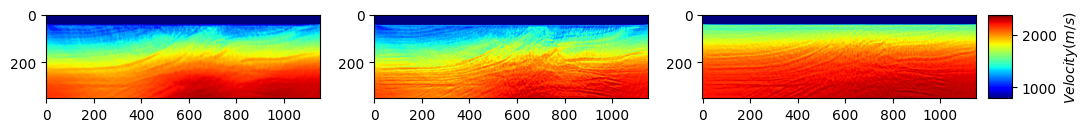

Iteration 25 = loss: 2.4435,model loss: 256873264.0000,time:6.93,snr_vp:18.481,snr_vs:18.431,snr_rho:22.944
Iteration 30 = loss: 2.3892,model loss: 254006408.0000,time:6.94,snr_vp:18.553,snr_vs:18.464,snr_rho:22.988
Iteration 35 = loss: 2.3422,model loss: 251410896.0000,time:6.94,snr_vp:18.622,snr_vs:18.500,snr_rho:23.023
Iteration 40 = loss: 2.3031,model loss: 249184676.0000,time:6.93,snr_vp:18.685,snr_vs:18.539,snr_rho:23.047


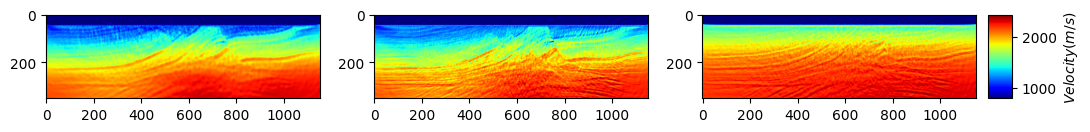

Iteration 45 = loss: 2.2704,model loss: 247199012.0000,time:6.94,snr_vp:18.744,snr_vs:18.583,snr_rho:23.062
Iteration 50 = loss: 2.2431,model loss: 245368040.0000,time:6.94,snr_vp:18.802,snr_vs:18.631,snr_rho:23.071
Iteration 55 = loss: 2.2199,model loss: 243630192.0000,time:6.94,snr_vp:18.859,snr_vs:18.681,snr_rho:23.074
Iteration 60 = loss: 2.1995,model loss: 241969572.0000,time:6.94,snr_vp:18.915,snr_vs:18.733,snr_rho:23.076


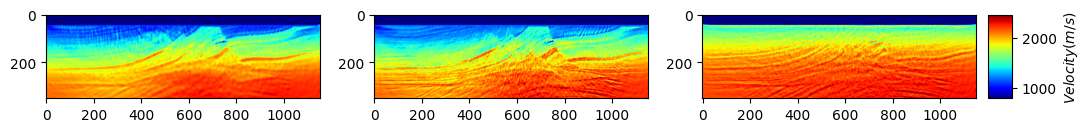

Iteration 65 = loss: 2.1812,model loss: 240369260.0000,time:8.03,snr_vp:18.970,snr_vs:18.788,snr_rho:23.077
Iteration 70 = loss: 2.1640,model loss: 238798228.0000,time:7.93,snr_vp:19.025,snr_vs:18.844,snr_rho:23.078
Iteration 75 = loss: 2.1475,model loss: 237213684.0000,time:7.93,snr_vp:19.079,snr_vs:18.902,snr_rho:23.080
Iteration 80 = loss: 2.1312,model loss: 235590612.0000,time:7.93,snr_vp:19.134,snr_vs:18.962,snr_rho:23.082


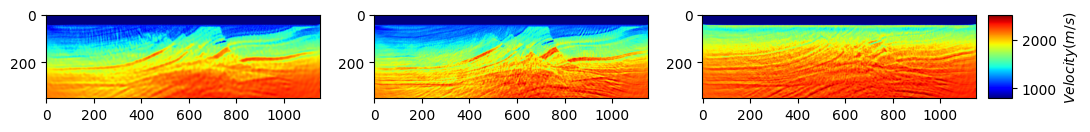

Iteration 85 = loss: 2.1139,model loss: 233900544.0000,time:7.93,snr_vp:19.190,snr_vs:19.028,snr_rho:23.087
Iteration 90 = loss: 2.0932,model loss: 232086132.0000,time:7.94,snr_vp:19.248,snr_vs:19.100,snr_rho:23.094
Iteration 95 = loss: 2.0566,model loss: 230167924.0000,time:7.93,snr_vp:19.308,snr_vs:19.172,snr_rho:23.110
Iteration 100 = loss: 2.0352,model loss: 228108480.0000,time:7.93,snr_vp:19.370,snr_vs:19.240,snr_rho:23.133


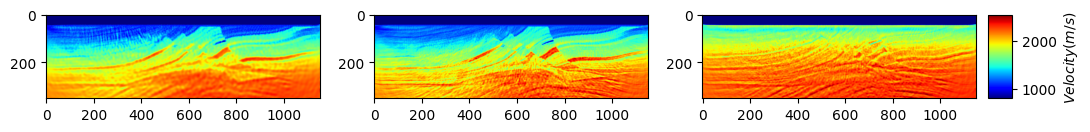

Iteration 105 = loss: 2.0213,model loss: 226017792.0000,time:7.93,snr_vp:19.433,snr_vs:19.303,snr_rho:23.158
Iteration 110 = loss: 2.0094,model loss: 223964544.0000,time:7.93,snr_vp:19.495,snr_vs:19.364,snr_rho:23.182
Iteration 115 = loss: 1.9992,model loss: 221951556.0000,time:7.93,snr_vp:19.556,snr_vs:19.422,snr_rho:23.204
Iteration 120 = loss: 1.9889,model loss: 219999324.0000,time:7.94,snr_vp:19.615,snr_vs:19.479,snr_rho:23.225


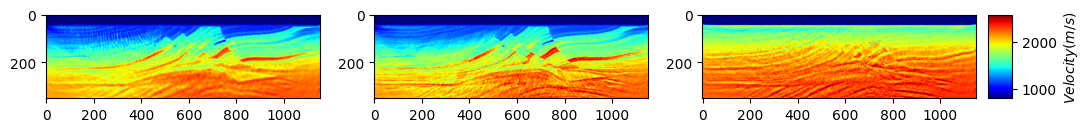

Iteration 125 = loss: 1.9797,model loss: 218115452.0000,time:7.93,snr_vp:19.672,snr_vs:19.536,snr_rho:23.247
Iteration 130 = loss: 1.9734,model loss: 216312344.0000,time:7.93,snr_vp:19.727,snr_vs:19.593,snr_rho:23.268


In [ ]:
# Run optimisation/inversion

# freqs_bands1 = [
#     (0.1, 3),
#     (0.1, 5),
#     (0.1, 7.5),
#     (0.1, 10),
#     (0.1, 15),
#     (0.1, 20),
# ]

# import time
t_start = time.time()
mini_batches = 5
ITERATION = 300 


levels  = 6

for iter in range(ITERATION):
    loss_data_minibatch = []
    
    time_each_bath_start = time.time()
    for batch in range(mini_batches):
   
        optimer.zero_grad()
    
        src_loc_batch = src_loc_encode[batch::mini_batches].to(DEVICE)
        rec_loc_batch = rec_loc_encode[batch::mini_batches].to(DEVICE)
        src_batch = src_encode[batch::mini_batches].to(DEVICE) ## for true source
            
        physics = Physics(inpa['dh'], inpa['dt'],inpa['fdom'] ,size=NT,src=src_batch,
                    src_loc=src_loc_batch, rec_loc=rec_loc_batch
                    )
        with torch.no_grad():
            vp[:submarine_deep,:] = submarine_vp
            vs[:submarine_deep,:] = submarine_vs
            rho[:submarine_deep,:] = submarine_rho
            vp[vp>vp_true.max()] = vp_true.max()
            vp[vp<vp_true.min()] = vp_true.min()
    
            vs[vs>vs_true.max()] = vs_true.max()
            vs[vs<vs_true.min()] = vs_true.min()
    
            rho[rho>rho_true.max()] = rho_true.max()
            rho[rho<rho_true.min()] = rho_true.min()
           
            vp = vp.requires_grad_(True)
            vs = vs.requires_grad_(True)
            rho = rho.requires_grad_(True)          
    
        vp = vp.to(DEVICE)
        vs = vs.to(DEVICE)
        rho = rho.to(DEVICE)
        

        taux_est = physics(vp,vs,rho) 
        taux_vx_est_filtered = taux_est[0].to(DEVICE)
        taux_vy_est_filtered = taux_est[1].to(DEVICE)
        
        taux_est_all = torch.cat((taux_vx_est_filtered,taux_vy_est_filtered),dim=1).to(DEVICE)
        
        d_obs_vx_filtered = d_obs_vx_encode[:, batch::mini_batches].to(DEVICE)
        d_obs_vy_filtered = d_obs_vy_encode[:, batch::mini_batches].to(DEVICE)
        
        d_obs_filtered_all = torch.cat((d_obs_vx_filtered,d_obs_vy_filtered),dim=1).to(DEVICE)


        kernel_size = 5
        channels = taux_est_all.shape[1]
        sigma = 3
        dtype = torch.float
        

        criteria = PyramidLoss(pyramid='laplacian', loss='l1',reduction = 'mean', levels=levels, channels=channels, 
                       kernel_size=kernel_size, sigma=sigma,
                       use_weights = True, # weight = 2^l
                       #weights = [1, 2, 4, 8, 16, 32, 64],
                       device=DEVICE)
        loss_data = 1.0e8*criteria(taux_est_all, d_obs_filtered_all)

        
        loss = loss_data
    
        loss.backward()
    
        optimer.step()

    all_loss_data.append(loss_data.detach().cpu().item())
    time_each_bath_end = time.time()
    time_each_iter.append(time_each_bath_end - time_each_bath_start)
    
    mem_now_cpu = get_cpu_memory()
    cpu_mem_log.append(mem_now_cpu)
    mem_now_gpu = get_gpu_memory()
    gpu_mem_log.append(mem_now_gpu)
    
    with torch.no_grad():
        all_loss_vx_model.append(
            criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()
        )
    
        all_loss_vy_model.append(
            criteria_model(vs.cpu(),vs_true.cpu()).detach().numpy().item()
            )
        all_loss_rho_model.append(
            criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
        )
        all_loss_model.append(
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
            )


    snr_vp = ComputeSNR(vp.detach().cpu().numpy(), \
              vp_true.detach().cpu().numpy())
    SNR_vp = np.append(SNR_vp, snr_vp)
    snr_vs = ComputeSNR(vs.detach().cpu().numpy(), \
              vs_true.detach().cpu().numpy())
    SNR_vs = np.append(SNR_vs, snr_vs)
    snr_rho = ComputeSNR(rho.detach().cpu().numpy(), \
              rho_true.detach().cpu().numpy())
    SNR_rho = np.append(SNR_rho, snr_rho)


    if (iter+1)%5 == 0:
        print(f"Iteration {iter + 1} = loss: {all_loss_data[-1]:.4f},model loss: {all_loss_model[-1]:.4f},time:{time_each_iter[-1]:.2f},snr_vp:{SNR_vp[-1]:.3f},snr_vs:{SNR_vs[-1]:.3f},snr_rho:{SNR_rho[-1]:.3f}")
    if (iter+1)%10==0:
        np.save(vp_save_path + 'recx_iter_%s.npy' % (iter + 1), vp.cpu().detach().numpy())
        np.save(vs_save_path + 'recx_iter_%s.npy' % (iter + 1), vs.cpu().detach().numpy())
        np.save(rho_save_path + 'recx_iter_%s.npy' % (iter + 1), rho.cpu().detach().numpy())
    if (iter+1)%20 == 0:
    
        fig, ax = plt.subplots(1,3,figsize=(12, 6))
        im0 = ax[0].imshow(vp.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        im1 = ax[1].imshow(vs.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        im2 = ax[2].imshow(rho.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        points = ax[1].get_position().get_points()
        dy = points[1, 1] - points[0, 1]
        cax = fig.add_axes([0.91, points[0, 1], 0.02, dy])
        cax.yaxis.set_ticks_position("right")
        cbar = fig.colorbar(im1, cax=cax, orientation="vertical", 
                        extend="neither", label="$Velocity (m/s)$"
                        )
        plt.show()
t_end = time.time()
elapsed_time = t_end - t_start
print('Running complete in {:.0f}m  {:.0f}s' .format(elapsed_time //60 , elapsed_time % 60))

In [ ]:

### path for log data
with torch.no_grad():
   
    np.savetxt(main_path+'all_loss_data.txt', all_loss_data,delimiter=',')
    np.savetxt(main_path+'all_loss_model.txt', all_loss_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vp_model.txt', all_loss_vx_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vs_model.txt', all_loss_vy_model, delimiter=',')
    np.savetxt(main_path+'all_loss_rho_model.txt', all_loss_rho_model, delimiter=',')
    
    np.savetxt(main_path+'vp_snr.txt', SNR_vp,delimiter=',')
    np.savetxt(main_path+'vs_snr.txt', SNR_vs,delimiter=',')
    np.savetxt(main_path+'rho_snr.txt', SNR_rho,delimiter=',')

    
    np.savetxt(main_path+'time.txt',time_each_iter , delimiter=',')
    
    np.savetxt(main_path+'cpu_men_log.txt',cpu_mem_log , delimiter=',')
    np.savetxt(main_path+'gpu_men_log.txt',gpu_mem_log , delimiter=',')
